
<h3 align="center">SA4110 MACHINE LEARNING APPLICATION DEVELOPMENT</h3>
<h4 align="center">CA - GROUP 3 - IMAGE CLASSIFIER</h4>
<hr>

<div class="alert alert-block alert-info">
<b><u>Tasks:</u></b> 
<ol>
<li>Create an Image Classifier (CNN model) to classify images of fruits correctly.</li>
<li>A Fruits Dataset is provided that consists of these 3 Classes: -</li>
    <ul>
    <li>Apple</li>
    <li>Banana</li>
    <li>Orange</li>
    </ul>
<li>Use the Images in train.zip and test.zip to Train and Test your Image Classifier.</li>
<li>Document your experiments and results in improving your model’s accuracy.</li>
<li>The Following Activities can Improve your Model’s Accuracy: -</li>
    <ul>
    <li>Balance out the Number of Samples in Each Class</li>
    <li>Correct any mis-labelling in any of the 3 Classes</li>
    <li>Image Augmentation to Generate more Data </li>
    </ul>
<li>Use Matplotlib to Generate any Plots that can Help the Reader understand your Work Better.</li>
</ol></div>



## Set Up
1. Installations
2. Imports

In [1]:
# ========================================================== #
# 1. (Optional) Verification of Base Libraries / Packages 
# Purpose: Verify that the host environment has the necessary
# packages or libraries required to run the script.
# ========================================================== #

import sys
import subprocess
import importlib.util

def verify_and_install():
    required_packages = {
        'pandas': 'pandas',
        'numpy': 'numpy',
        'matplotlib': 'matplotlib',
        'seaborn': 'seaborn',
        'IPython': 'ipython',
        'PIL': 'Pillow',
        'torch': 'torch',
        'torchvision': 'torchvision',
        'keras': 'keras',
        'sklearn': 'scikit-learn'
    }

    print("--- Verifying Environment Setup ---")
    
    for import_name, pip_name in required_packages.items():
        # Check if the module can be found in the host environment
        if importlib.util.find_spec(import_name) is None:
            print(f"❌ '{import_name}' is missing. Installing '{pip_name}'...")
            try:
                # Run pip install securely via the current python executable
                subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
                print(f"✅ Successfully installed '{pip_name}'.")
            except subprocess.CalledProcessError as e:
                # Stop the script if a critical package fails to install
                print(f"⚠️ Failed to install '{pip_name}'. Error: {e}")
                sys.exit(1) 
        else:
            print(f"✅ '{import_name}' is already installed.")
            
    print("-" * 70)
    print("All necessary packages are ready. Proceeding with the script...")
    print("-" * 70 + "\n")

# Run the verification before importing the third-party libraries
verify_and_install()

--- Verifying Environment Setup ---
✅ 'pandas' is already installed.
✅ 'numpy' is already installed.
✅ 'matplotlib' is already installed.
✅ 'seaborn' is already installed.
✅ 'IPython' is already installed.
✅ 'PIL' is already installed.
✅ 'torch' is already installed.
✅ 'torchvision' is already installed.
✅ 'keras' is already installed.
✅ 'sklearn' is already installed.
----------------------------------------------------------------------
All necessary packages are ready. Proceeding with the script...
----------------------------------------------------------------------



In [2]:
# ========================================================== #
# 2. Importing the Required Libraries and Packages
# Purpose: Import the Libraries and Packages to the Host
# Environment for Data Manipulation, Visualization, Image Processing,
# Deep Learning, and Machine Learning Utilities.
# ========================================================== #

# A. System and OS-level operations
import os
import gc
import statistics
from pathlib import Path
os.environ["KERAS_BACKEND"] = "torch"

# B. Data Manipulation and Mathematical Operations
import pandas as pd
import numpy as np

# C. Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# D. Image Processing
from PIL import Image

# E. Deep Learning Frameworks (PyTorch & Keras)
import torch
import keras
from keras import layers
from keras import backend as K
from keras.models import Sequential
from keras.layers import (Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout)
from keras.optimizers import Adam
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

# F. Machine Learning Utilities and Metrics (Scikit-Learn)
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# G. Time reporting
import time

# Clear session and random seeds
import random

K.clear_session()

def set_seeds(seed=42):
    # 1. Python
    random.seed(seed)
    
    # 2. NumPy operations
    np.random.seed(seed)
    
    # 3. Core PyTorch CPU operations
    torch.manual_seed(seed)
    
    # Keras setting
    keras.utils.set_random_seed(seed)
    
    print(f"✅ All random seeds locked globally to: {seed}")

# Execute the function
set_seeds(42)

✅ All random seeds locked globally to: 42


## Image Preprocessing
1. Load image from Test and Train folders
2. Preprocess and label images
3. Data preparation

In [3]:
# ========================================================== #
# 3. Helper functions to render HTML components for display
# ========================================================== #
# Render dataframe as HTML table
def render_df(df, sample_size):

    # Dynamic sampling based on input size
    display_df = (
        df if sample_size == 0
        else df.sample(n=min(sample_size, len(df)))
    )
    
    return (display_df.style
        .set_properties(**{'text-align': 'center', 'color': 'black'})
        .set_table_styles([
            {'selector':'tr:nth-child(even)', 'props': [('background-color', 'azure')]},
            {'selector':'th', 'props':[('text-align', 'center'), ('color', 'black'), ('font-weight', 'bold')]},
            {'selector':'tr:nth-child(odd)', 'props':[('text-align', 'center'), ('background-color', 'paleturquoise')]}
        ])).to_html()

# Render section header as HTML line
def render_section_header(title):
    return f"<h4 style='text-align: left; margin-top: 15px; margin-bottom: 5px;'>{title}</h4>"

# Label value table
def render_key_value_table(rows):
    """
    rows = [
        ("Label 1", "Value 1"),
        ("Label 2", "Value 2"),
    ]
    """

    html = "<table style='margin: 0; text-align: left; border: none;'>"

    for i, (label, value) in enumerate(rows):
        bg = "paleturquoise" if i % 2 == 0 else "azure"

        html += f"""
        <tr style='background-color: {bg};'>
            <td style='color: black;
                       text-align: center;
                       padding-right: 10px;
                       border: none;'>
                <strong>{label}</strong>
            </td>
            <td style='color: black;
                       text-align: center;
                       border: none;'>
                {value}
            </td>
        </tr>
        """

    html += "</table>"
    return html

# Status messages
def render_status_list(messages):
    """
    messages = [
        ("green", "Success"),
        ("red", "Failure")
    ]
    """

    html = "<ul style='text-align: left;'>"

    for color, msg in messages:
        html += f"<li style='color: {color};'>{msg}</li>"

    html += "</ul>"
    return html

# Line separator
def render_separator():
    return "<hr style='margin-top: 15px; border-top: 1px solid #ddd;'>"

# Not found message
def render_no_images_message():
    return "<div style='color: red; text-align: center;'>No valid .jpg images found.</div>"

# Display dataset inspect
def render_dataset_info(train_logs, train_html, test_logs, test_html):
    return f"""
    <div style="display: flex; flex-direction: row; justify-content: space-around; align-items: flex-start; gap: 20px;">
        <div style="flex: 1; padding: 10px; border: 1px solid #ccc; border-radius: 16px;">
            <h3 style="text-align: center; color: 'black';">Training & Validation Dataset</h3>
            <div style="display: flex; flex-direction: column; justify-content: center;">
                {train_logs}
            </div>
            <h4 style="text-align: left;">DataFrame Sample</h4>
            <div style="display: flex; flex-direction: column; justify-content: center;">
                {train_html}
            </div>
        </div>
        
        <div style="flex: 1; padding: 10px; border: 1px solid #ccc; border-radius: 16px;">
            <h3 style="text-align: center; color: 'black';">Testing Dataset</h3>
            <div style="display: flex; flex-direction: column; justify-content: center;">
                {test_logs}
            </div>
            <h4 style="text-align: left;">DataFrame Sample</h4>
            <div style="display: flex; flex-direction: column; justify-content: center;">
                {test_html}
            </div>
        </div>
    </div>
    """

# Display data set info
def render_dataset_shapes(train_shape_html, val_shape_html, class_test_shape_html):
    return f"""
    <div style="display: flex; flex-direction: row; justify-content: space-around; align-items: flex-start; gap: 20px;">
        <div style="flex: 1; padding: 10px; border: 1px solid #ccc; border-radius: 16px;">
            <h3 style="text-align: center; color: 'black';">Training (80%)<br>Dataset Shape</h3>
            <div style="display: flex; flex-direction: column; justify-content: center;">
                {train_shape_html}
            </div>
        </div>
        
        <div style="flex: 1; padding: 10px; border: 1px solid #ccc; border-radius: 16px;">
            <h3 style="text-align: center; color: 'black';">Validation (20%)<br>Dataset Shape</h3>
            <div style="display: flex; flex-direction: column; justify-content: center;">
                {val_shape_html}
            </div>
        </div>
    
        <div style="flex: 1; padding: 10px; border: 1px solid #ccc; border-radius: 16px;">
            <h3 style="text-align: center; color: 'black';">Testing<br>Dataset Shape</h3>
            <div style="display: flex; flex-direction: column; justify-content: center;">
                {class_test_shape_html}
            </div>
        </div>
    </div>
    """

In [4]:
# ========================================================== #
# 4. Load and Process the Image Data from the Directories
# Purpose: Scan the 'train' and 'test' directories for .jpg 
# images, extract class labels from filenames, calculate 
# median dimensions, and compile the data into DataFrames 
# for prior for model training and evaluation.
# ========================================================== #

def process_image_directory(directory_path, dataset_name="Dataset"):
    
    file_names = []
    class_labels = []
    widths = []
    heights = []
    status_messages = []

    # Single pass through the directory
    for img_path in directory_path.glob("*.jpg"):
        try:
            # A. Open a valid data image file and extract its dimensions
            with Image.open(img_path) as img:
                widths.append(img.size[0])
                heights.append(img.size[1])
                
            # B. Extract metadata ONLY if the image opened successfully
            file_names.append(img_path.name)
            class_labels.append(img_path.name.strip().split('_')[0])
            
        except Exception as e:
            # C. Exception handling for invalid data image file
            status_messages.append(("red", f"Error reading {img_path.name}: {e}"))

    # Success message if no errors
    if not status_messages:
        status_messages.append(("green", "All images read successfully without errors."))

    # Build the DataFrame Table of Consisting of File Name and its Classes
    df = pd.DataFrame({
        'fileName': file_names,
        'classLabel': class_labels
    })

    # Build HTML Report

    log_html = ""

    log_html += render_section_header("Processing Status")
    log_html += render_status_list(status_messages)

    log_html += render_section_header("Class Labels Found")
    log_html += render_key_value_table([
        (f"Class {i}", label)
        for i, label in enumerate(df['classLabel'].unique(), start = 1)
    ])

    # Calculate Medians of the data images 
    median_w, median_h = 0, 0
    log_html += render_section_header("<br>Dataset Statistics")
    
    if widths and heights:
        median_w = statistics.median(widths)
        median_h = statistics.median(heights)
        
        log_html += render_key_value_table([
            ("Total Images Evaluated", len(widths)),
            ("Image Median Width", f"{median_w} px"),
            ("Image Median Height", f"{median_h} px")
        ])
    else:
        log_html += render_no_images_message()
        
    log_html += render_separator()
        
    return df, median_w, median_h, log_html

In [5]:
# ---------------------------------------------------------- #
# Execute the Function for Both Directories
# ---------------------------------------------------------- #

# Define the path directories
base_dir = Path.cwd().parents[0]
img_train_dir = base_dir / "train"
img_test_dir = base_dir / "test"

# Process Training and Validation Datasets from 'train' directory
class_train_df, img_T_widths_median, img_T_heights_median, train_logs = process_image_directory(
    directory_path = img_train_dir, 
    dataset_name = "Training and Validation Dataset"
)

# Sampling of the training and validation dataframe for verification
train_html = render_df(class_train_df, 5)

# Process Testing Datasets from 'test' directory
class_test_df, img_t_widths_median, img_t_heights_median, test_logs = process_image_directory(
    directory_path = img_test_dir, 
    dataset_name = "Testing Dataset"
)

# Sampling of the testing dataframe for verification
test_html = render_df(class_test_df, 5)

# Wrapping them html in a Flex container to enable side-by-side display
train_test_html = render_dataset_info(train_logs, train_html, test_logs, test_html)
display(HTML(train_test_html))

In [6]:
# ========================================================== #
# 5. Define a New Class: FruitLabeller and Supporting Functions
# Purpose: Create a custom PyTorch Dataset to load images, apply 
# transformations, and encode string labels to numeric indices 
# using a provided DataFrame. Includes a helper function to 
# visually summarize the dataset's class distribution.
# ========================================================== #

class FruitLabeller(Dataset):
    def __init__(self, class_dataframe, img_directory, transforms = None):
        self.dataframe = class_dataframe
        self.directory = img_directory
        self.transforms = transforms

        unique_labels = sorted(class_dataframe['classLabel'].unique())
        self.label_map = {label: idx for idx, label in enumerate(unique_labels)}
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx]['fileName']
        img_path = self.directory / img_name
        image = Image.open(img_path).convert("RGB")

        label_str = self.dataframe.iloc[idx]['classLabel']
        label = self.label_map[label_str]

        if self.transforms:
            image = self.transforms(image)
        
        return image, label
    
def render_dataset_shape(df):
    shape_df = df['classLabel'].value_counts().sort_index().reset_index()
    shape_df.columns = ['Class Label', 'Total Image']
    return shape_df

In [7]:
# ========================================================== #
# 6. Data preparation
# ========================================================== #

# Set Target Size (Max 224x224)
target_width = int(img_T_widths_median) if img_T_widths_median < 224 else 224
target_height = int(img_T_heights_median) if img_T_heights_median < 224 else 224

# Split Data (80% Train, 20% Val)
train_df, val_df = train_test_split(
    class_train_df,
    test_size=0.2,
    random_state=42,
    stratify=class_train_df['classLabel']
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

# Define PyTorch Transformations
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop((target_height, target_width)),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop((target_height, target_width)),
    transforms.ToTensor()
])

# Instantiate PyTorch Datasets
train_dataset = FruitLabeller(train_df, img_train_dir, train_transforms)
val_dataset = FruitLabeller(val_df, img_train_dir, test_transforms)
test_dataset = FruitLabeller(class_test_df, img_test_dir, test_transforms)

# Create PyTorch DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Display Dataset Shapes
train_shape_html = render_df(render_dataset_shape(train_df), 0)
val_shape_html = render_df(render_dataset_shape(val_df), 0)
class_test_shape_html = render_df(render_dataset_shape(class_test_df), 0)

# Wrapping them html in a Flex container to enable side-by-side display
dataset_shapes_html = render_dataset_shapes(train_shape_html, val_shape_html, class_test_shape_html)

display(HTML(dataset_shapes_html))

,Class Label,Total Image
0,apple,60
1,banana,58
2,orange,58
,Class Label,Total Image
0,apple,15
1,banana,15
2,orange,14
,Class Label,Total Image
0,apple,19
1,banana,18


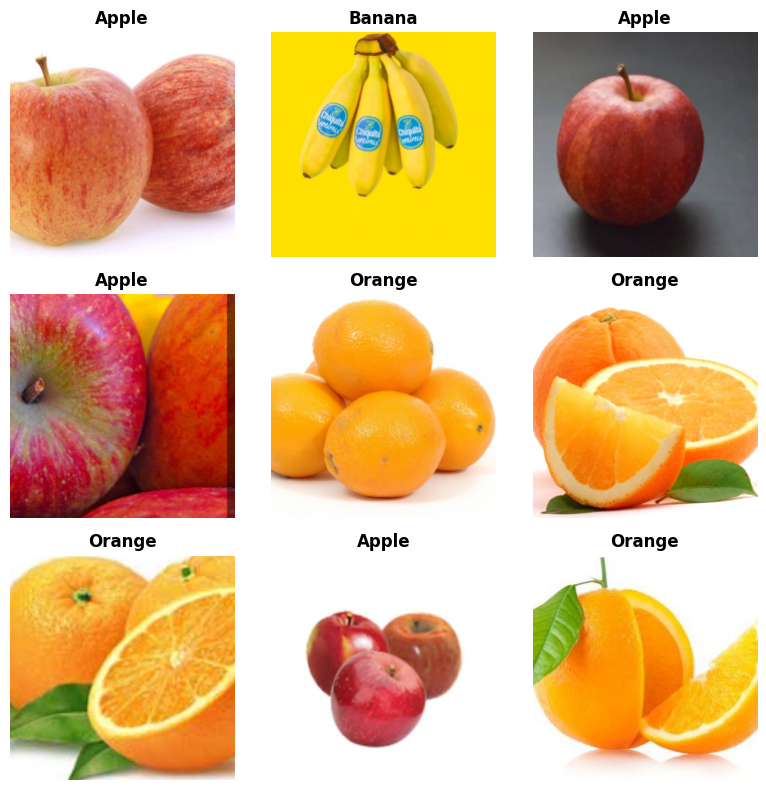

In [8]:
# Display Sample Images
images, labels = next(iter(train_loader))
class_names = {v: k for k, v in train_dataset.label_map.items()}

# Set up a MatPlotLib Grid
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    img = np.transpose(images[i].numpy(), (1, 2, 0))
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    
    # Look up the Integer Label in the Dictionary and Set it as the Title
    label_idx = labels[i].item()
    ax.set_title(class_names[label_idx].capitalize(), fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

## Experiment 1: Baseline Model
1. Build CNN architecture
2. Compile model
3. Train model
4. Evaluate model

In [9]:
# ========================================================== #
# 7. Build and Compile CNN Architecture (224 x 224 x 3)
# Model is coded to be configurable for experimentation
# By default no dropout or augmentation
# ========================================================== #
def build_model(dropout_rate = 0.0, data_augmentation = None):
    model_layers = []

    model_layers.append(Input(shape=(3, 224, 224)))
    
    # Only add augmentation if passed in
    if data_augmentation:
        model_layers.extend(data_augmentation)
    
    # Default settings
    model_layers.extend([    
        # Conv1: 32 filters, Output shape: 224 x 224 x 32
        # Scans the raw image using a kernel to detect basic, low-level spatial features
        Conv2D(
            filters=32,
            kernel_size=(3, 3),
            padding="same",
            activation="relu",
            data_format="channels_first" # PyTorch default
        ),
    
        # MaxPool: 224 x 224 -> 112 x 112
        # Downsamples feature maps with the maximum value from a 2 x 2 window
        # Reduces computational cost, controls overfitting, and makes the network 
        # robust to small shifts or translations in the image.
        MaxPooling2D(pool_size=(2, 2), data_format="channels_first"),
    
        # Conv2: 64 filters, output shape: 112 x 112 x 64
        # Scans pooled feature maps again with an increased num of filters (64) to learn 
        # higher-level, more complex and abstract features
        Conv2D(
            filters=64,
            kernel_size=(3, 3),
            padding="same",
            activation="relu",
            data_format="channels_first"
        ),
    
        # MaxPool: 112 x 112 -> 56 x 56
        MaxPooling2D(pool_size=(2, 2), data_format="channels_first"),
        
        
        # Conv3: 128 filters, output shape: 56 x 56 x 128
        # Scans pooled feature maps again with an increased num of filters (128) to learn 
        # higher-level, more complex and abstract features
        Conv2D(
            filters=128,
            kernel_size=(3, 3),
            padding="same",
            activation="relu",
            data_format="channels_first"
        ),
    
        # MaxPool: 56 x 56 -> 28 x 28
        MaxPooling2D(pool_size=(2, 2), data_format="channels_first"),

        # Dropout layer
        Dropout(dropout_rate),
        
        # Flatten: 28 x 28 x 128 = 100,352
        # Flattens conv layers (3D tensors) into a 1D vector as required by Dense layers
        Flatten(),
    
        # Fully connected layer
        # learns correlations between combined features and specific fruit classes
        Dense(128, activation="relu"),
        
        # Output Layer: 3 nodes (Apples, Bananas, Oranges)
        # PURPOSE: Produces the final prediction. 
        # - activation ('softmax'): Converts the raw output scores into a probability 
        # distribution, where all outputs sum up to 1. The highest probability is the prediction.
        Dense(3, activation='softmax')
    ])

    return Sequential(model_layers)

# Build model
baseline_model = build_model()

In [11]:
# ========================================================== #
# 8. Compile model
# Optimizer: Adam - Update weights while learning
# Loss: Sparse categorical crossentropy - Numerical labels
# Metrics: Accuracy - Measure correct / total preds
# ========================================================== #
def compile_model(model, learning_rate = 0.001):
    model.compile(
        optimizer=Adam(
            learning_rate=learning_rate
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

compile_model(baseline_model, 0.001)

# Model summary
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 224, 224)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 112, 112)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 112, 112)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 56, 56)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 56, 56)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 128, 28, 28)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 28, 28)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,819 (49.36 MB)

 Trainable params: 12,938,819 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# ========================================================== #
# 9. Train CNN Model
# Epochs at 20 to allow liberal and fair experimentation
# Track processing time for experiment comparison
# ========================================================== #

# To store training/inference times for experiment comparison
# from sklearn import callback


processing_times = {}

def train_model(model_type, model, epoc):
    start = time.perf_counter()
    
    class GarbageCollectorCallback(keras.callbacks.Callback):
        def on_epoch_end(self, epoch, logs=None):
            gc.collect()

    history = model.fit(
        train_loader,
        validation_data = val_loader,
        epochs = epoc,
        callbacks = [GarbageCollectorCallback()]
    )

    end = time.perf_counter()
    training_time = end - start

    processing_times[(model_type.lower() + '_training_time')] = training_time # Store time in dict

    return history

baseline_history = train_model('baseline', baseline_model, 20)

Epoch 1/20
 2/11 ━━━━━━━━━━━━━━━━━━━━ 4s 490ms/step - accuracy: 0.2969 - loss: 3.2715

C:\Users\user\AppData\Roaming\Python\Python314\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.4034 - loss: 2.9443 - val_accuracy: 0.7727 - val_loss: 0.7497
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.7955 - loss: 0.5694 - val_accuracy: 0.9545 - val_loss: 0.2118
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 806ms/step - accuracy: 0.9091 - loss: 0.2701 - val_accuracy: 0.9318 - val_loss: 0.2252
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 745ms/step - accuracy: 0.9318 - loss: 0.2236 - val_accuracy: 0.8864 - val_loss: 0.3309
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 762ms/step - accuracy: 0.9659 - loss: 0.0980 - val_accuracy: 0.9545 - val_loss: 0.1231
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 720ms/step - accuracy: 0.9830 - loss: 0.0648 - val_accuracy: 0.9318 - val_loss: 0.1730
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 725ms/step - accuracy: 0.9830 - loss: 0.0411 - val_accuracy: 0.9318 - val_loss: 0.1099
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 745ms/step - accuracy: 1.0000 - loss: 0.0161 - val_accuracy: 0.9318 - val_loss

In [13]:
# Helpers to prepare for model evaluation
# Configured to be reusable for every experiment

# Get predictions for model
# Track processing time for experiment comparison
def get_predictions(model_type, model):

    start = time.perf_counter()
    
    # Initialize lists to store true and predicted labels for the entire dataset
    y_true = []
    y_pred = []
    
    # Iterate through the entire test_loader
    for images, labels in test_loader:
        # Get predictions for the current batch (verbose=0 suppresses per-batch output)
        batch_preds_prob = model.predict(images, verbose=0)
        batch_preds = np.argmax(batch_preds_prob, axis=1)
        
        # Append the results to the tracking lists
        y_true.extend(labels.numpy())
        y_pred.extend(batch_preds)

    end = time.perf_counter()
    inference_time = end - start
    processing_times[(model_type.lower() + '_inference_time')] = inference_time # Store time in dict

    return y_true, y_pred

# Set target names
target_names = [
    name for name in train_dataset.label_map.keys()
]

# Evaluation result builder
def build_result(
    model_name,
    history,
    y_true,
    y_pred,
):
    report = classification_report(
        y_true, 
        y_pred,
        target_names = target_names,
        output_dict = True
    )

    return {
        'name': model_name,
        'history': history,

        # For experiment comparison
        'accuracy': report['accuracy'],
        'precision': report['macro avg']['precision'],
        'recall': report['macro avg']['recall'],
        'f1': report['macro avg']['f1-score'],

        # For individual reporting
        'classification_report': pd.DataFrame(report)
            .transpose()
            .round(3),
        'confusion_matrix': confusion_matrix(y_true, y_pred)
    }

# Generate and render accuracy and loss graphs
def render_accuracy_loss_report(model_name, history, test_loss, test_accuracy):
    
    # Extract Key Metrics from the History object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)
    
    sns.set_theme(style='darkgrid')
    plt.figure(figsize=(12, 5))
    
    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o', color='blue')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o', color='darkorange')
    plt.title('Training and Validation Accuracy', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs', fontsize=10, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=10, fontweight='bold')
    plt.legend(loc='lower right')
    plt.xlim(0,21)
    plt.ylim(0,1.1)
    plt.grid(True)
    
    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o', color='blue')
    plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o', color='darkorange')
    plt.title('Training and Validation Loss', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs', fontsize=10, fontweight='bold')
    plt.ylabel('Loss', fontsize=10, fontweight='bold')
    plt.legend(loc='upper right')
    plt.xlim(0,21)
    plt.grid(True)
    
    plt.tight_layout()

    # Save figure as image
    filename = (f"{model_name.lower().replace(' ', '_')}_history.png")
    plt.savefig(filename)
    plt.close()

    # Return as HTML report
    return (
        render_section_header(
            f"Accuracy and Loss: {model_name}"
        )
        + f"""
        <p><b>Final Test Loss:</b> {test_loss:.4f}<br><b>Final Test Accuracy:</b> {test_accuracy:.4f}</p>

        <img src="{filename}"
             width="800">
        """
    )

# Generate and render accuracy and loss graphs
def render_accuracy_loss_report_epoch30(model_name, history, test_loss, test_accuracy):
    
    # Extract Key Metrics from the History object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)
    
    sns.set_theme(style='darkgrid')
    plt.figure(figsize=(12, 5))
    
    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o', color='blue')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o', color='darkorange')
    plt.title('Training and Validation Accuracy', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs', fontsize=10, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=10, fontweight='bold')
    plt.legend(loc='lower right')
    plt.xlim(0,31)
    plt.ylim(0,1.1)
    plt.grid(True)
    
    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o', color='blue')
    plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o', color='darkorange')
    plt.title('Training and Validation Loss', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs', fontsize=10, fontweight='bold')
    plt.ylabel('Loss', fontsize=10, fontweight='bold')
    plt.legend(loc='upper right')
    plt.xlim(0,31)
    plt.grid(True)
    
    plt.tight_layout()

    # Save figure as image
    filename = (f"{model_name.lower().replace(' ', '_')}_history.png")
    plt.savefig(filename)
    plt.close()

    # Return as HTML report
    return (
        render_section_header(
            f"Accuracy and Loss: {model_name}"
        )
        + f"""
        <p><b>Final Test Loss:</b> {test_loss:.4f}<br><b>Final Test Accuracy:</b> {test_accuracy:.4f}</p>

        <img src="{filename}"
             width="800">
        """
    )

# Render classification report
def render_classification_report(result):
    html = render_section_header(f"Classification Report: {result['name']}")
    html += render_df(result['classification_report'], 0)
    return html

# Render confusion matrix
def render_confusion_matrix(result):
    cm = result['confusion_matrix']
    model_name = result['name']
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, 
                yticklabels=target_names)
    # plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')

    # Save figure as image
    filename = (f"{model_name.lower().replace(' ', '_')}_cm.png")
    plt.savefig(filename)
    plt.close()

    # Return as HTML report
    return (
        render_section_header(
            f"Confusion Matrix: {model_name}"
        )
        + f"""
        <img src="{filename}"
             width="800">
        """
    )

# Render Processing time
def render_processing_time(result, training_time, inference_time):
    model_name = result['name']
    return (
        render_section_header(
            f"Processing Time: {model_name}"
        )
        + f"""
            <p><b>Training Time:</b> {training_time:.4f}s<br><b>Inference Time:</b> {inference_time:.4f}s</p>
        """
    )

# Display all evaluation results
def display_evaluation_results(accuracy_loss_report, class_report, confusion_matrix, processing_time):
    display(HTML(accuracy_loss_report))
    display(HTML(class_report))
    display(HTML(confusion_matrix))
    display(HTML(processing_time))

In [14]:
# ========================================================== #
# 10. Evaluate Baseline Model
# Configured to be reused on evaluation of experiments
# ========================================================== #

# Get predictions for model
y_true, y_pred, = get_predictions("baseline", baseline_model)

# Build evaluation result
baseline_result = build_result(
    "Baseline Model",
    baseline_history,
    y_true,
    y_pred,
)

# Generate and render Accuracy and Loss Report
test_loss, test_accuracy = baseline_model.evaluate(test_loader, verbose = 0)
baseline_accuracy_loss_report = render_accuracy_loss_report("Baseline Model", baseline_history, test_loss, test_accuracy)

# Generate and render Classification Report from result
baseline_class_report = render_classification_report(baseline_result)

# Generate and render Confusion Matrix
baseline_confusion_matrix = render_confusion_matrix(baseline_result)

# Render processing time
baseline_processing_time = render_processing_time(baseline_result, processing_times['baseline_training_time'], processing_times['baseline_inference_time'])

# Display evaluation results
display_evaluation_results(baseline_accuracy_loss_report, baseline_class_report, baseline_confusion_matrix, baseline_processing_time)

,precision,recall,f1-score,support
apple,0.950000,1.000000,0.974000,19.000000
banana,1.000000,0.833000,0.909000,18.000000
orange,0.900000,1.000000,0.947000,18.000000
accuracy,0.945000,0.945000,0.945000,0.945000
macro avg,0.950000,0.944000,0.944000,55.000000
weighted avg,0.950000,0.945000,0.944000,55.000000


## Experiment 2: Improved Model with Hyperparameter Tuning
1. Rebuild CNN architecture
2. Compile model
3. Train model
4. Evaluate model

In [51]:
# ====================================================================== #
# 11. Compile and Train Model with Learning Rate at 0.0005, Epochs = 20
# ====================================================================== #

LR_0005_model = build_model(0.0, False)
compile_model(LR_0005_model, 0.0005)

# Model summary
LR_0005_model.summary()

LR_0005_history = train_model('LR_0005', LR_0005_model, 20)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 224, 224)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 112, 112)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 112, 112)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 56, 56)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 56, 56)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 128, 28, 28)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128, 28, 28)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,819 (49.36 MB)

 Trainable params: 12,938,819 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
 2/11 ━━━━━━━━━━━━━━━━━━━━ 5s 574ms/step - accuracy: 0.2656 - loss: 1.6460

C:\Users\user\AppData\Roaming\Python\Python314\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


11/11 ━━━━━━━━━━━━━━━━━━━━ 47s 5s/step - accuracy: 0.6023 - loss: 1.3498 - val_accuracy: 0.9091 - val_loss: 0.3709
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 46s 4s/step - accuracy: 0.8239 - loss: 0.5431 - val_accuracy: 0.8409 - val_loss: 0.4569
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.8182 - loss: 0.4531 - val_accuracy: 0.7727 - val_loss: 0.4364
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.9091 - loss: 0.2896 - val_accuracy: 0.8864 - val_loss: 0.3255
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9489 - loss: 0.1901 - val_accuracy: 0.8636 - val_loss: 0.4268
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.9659 - loss: 0.0883 - val_accuracy: 0.9091 - val_loss: 0.2235
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 736ms/step - accuracy: 0.9773 - loss: 0.0553 - val_accuracy: 0.9545 - val_loss: 0.1110
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 649ms/step - accuracy: 0.9886 - loss: 0.0387 - val_accuracy: 0.9545 - val_loss: 0.0863

In [52]:
# =============================================================== #
# 12. Evaluate Model with Learning Rate at 0.0005, Epochs = 20
# =============================================================== #

# Get predictions for model
y_true, y_pred, = get_predictions("LR_0005", LR_0005_model)

# Build evaluation result
LR_0005_result = build_result(
    "Learning Rate 0.0005 Model",
    LR_0005_history,
    y_true,
    y_pred,
)

# Generate and render Accuracy and Loss Report
LR_0005_test_loss, LR_0005_test_accuracy = LR_0005_model.evaluate(test_loader, verbose = 0)
LR_0005_accuracy_loss_report = render_accuracy_loss_report("Learning Rate 0.0005 Model", LR_0005_history, LR_0005_test_loss, LR_0005_test_accuracy, 20)

# Generate and render Classification Report from result
LR_0005_class_report = render_classification_report(LR_0005_result)

# Generate and render Confusion Matrix
LR_0005_confusion_matrix = render_confusion_matrix(LR_0005_result)

# Render processing time
LR_0005_processing_time = render_processing_time(LR_0005_result, processing_times['lr_0005_training_time'], processing_times['lr_0005_inference_time'])

# Display evaluation results
display_evaluation_results(LR_0005_accuracy_loss_report, LR_0005_class_report, LR_0005_confusion_matrix, LR_0005_processing_time)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 224, 224)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 112, 112)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 112, 112)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 64, 56, 56)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 128, 56, 56)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 128, 28, 28)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128, 28, 28)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,819 (49.36 MB)

 Trainable params: 12,938,819 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.3636 - loss: 1.8165 - val_accuracy: 0.3409 - val_loss: 1.0440
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.5284 - loss: 0.8892 - val_accuracy: 0.8409 - val_loss: 0.5653
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.7386 - loss: 0.6223 - val_accuracy: 0.7955 - val_loss: 0.4257
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.8864 - loss: 0.3471 - val_accuracy: 0.9091 - val_loss: 0.2372
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9602 - loss: 0.2191 - val_accuracy: 0.9091 - val_loss: 0.2100
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.9602 - loss: 0.1230 - val_accuracy: 0.9091 - val_loss: 0.2185
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 850ms/step - accuracy: 0.9773 - loss: 0.0567 - val_accuracy: 0.9091 - val_loss: 0.2730
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 702ms/step - accuracy: 0.9716 - loss: 0.0757 - val_accuracy: 0.8864 - val_

In [53]:
# ====================================================================== #
# 13. Compile and Train Model with Learning Rate at 0.00001, Epochs = 30
# ====================================================================== #

LR_00001_model = build_model(0.0, False)
compile_model(LR_00001_model, 0.00001)

# Model summary
LR_00001_model.summary()

LR_00001_history = train_model('LR_00001', LR_00001_model, 30)

,precision,recall,f1-score,support
apple,0.950000,1.000000,0.974000,19.000000
banana,1.000000,0.944000,0.971000,18.000000
orange,1.000000,1.000000,1.000000,18.000000
accuracy,0.982000,0.982000,0.982000,0.982000
macro avg,0.983000,0.981000,0.982000,55.000000
weighted avg,0.983000,0.982000,0.982000,55.000000


In [54]:
# =============================================================== #
# 14. Evaluate Model with Learning Rate at 0.00001, Epochs = 30
# =============================================================== #

# Get predictions for model
y_true, y_pred, = get_predictions("LR_00001", LR_00001_model)

# Build evaluation result
LR_00001_result = build_result(
    "Learning Rate 0.00001 Model",
    LR_00001_history,
    y_true,
    y_pred,
)

# Generate and render Accuracy and Loss Report
LR_00001_test_loss, LR_00001_test_accuracy = LR_00001_model.evaluate(test_loader, verbose = 0)
LR_00001_accuracy_loss_report = render_accuracy_loss_report("Learning Rate 0.00001 Model", LR_00001_history, LR_00001_test_loss, LR_00001_test_accuracy, 30)

# Generate and render Classification Report from result
LR_00001_class_report = render_classification_report(LR_00001_result)

# Generate and render Confusion Matrix
LR_00001_confusion_matrix = render_confusion_matrix(LR_00001_result)

# Render processing time
LR_00001_processing_time = render_processing_time(LR_00001_result, processing_times['lr_00001_training_time'], processing_times['lr_00001_inference_time'])

# Display evaluation results
display_evaluation_results(LR_00001_accuracy_loss_report, LR_00001_class_report, LR_00001_confusion_matrix, LR_00001_processing_time)

,precision,recall,f1-score,support
apple,0.905000,1.000000,0.950000,19.000000
banana,1.000000,0.889000,0.941000,18.000000
orange,0.944000,0.944000,0.944000,18.000000
accuracy,0.945000,0.945000,0.945000,0.945000
macro avg,0.950000,0.944000,0.945000,55.000000
weighted avg,0.949000,0.945000,0.945000,55.000000


In [55]:
# ====================================================================== #
# 15. Compile and Train Model with Learning Rate at 0.000005, Epochs = 30
# ====================================================================== #

LR_000005_model = build_model(0.0, False)
compile_model(LR_000005_model, 0.000005)

# Model summary
LR_000005_model.summary()

LR_000005_history = train_model('LR_000005', LR_000005_model, 30)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 32, 224, 224)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 112, 112)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 112, 112)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 64, 56, 56)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 128, 56, 56)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 128, 28, 28)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128, 28, 28)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,819 (49.36 MB)

 Trainable params: 12,938,819 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
 6/11 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.2540 - loss: 5.2261

C:\Users\user\AppData\Roaming\Python\Python314\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


11/11 ━━━━━━━━━━━━━━━━━━━━ 65s 6s/step - accuracy: 0.3352 - loss: 3.8894 - val_accuracy: 0.3636 - val_loss: 0.9952
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 69s 6s/step - accuracy: 0.6307 - loss: 0.8506 - val_accuracy: 0.7727 - val_loss: 0.5437
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.8580 - loss: 0.4302 - val_accuracy: 0.9773 - val_loss: 0.1626
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.9091 - loss: 0.2682 - val_accuracy: 0.9091 - val_loss: 0.1988
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 654ms/step - accuracy: 0.9545 - loss: 0.1468 - val_accuracy: 0.9318 - val_loss: 0.2626
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 633ms/step - accuracy: 0.9659 - loss: 0.0868 - val_accuracy: 0.9318 - val_loss: 0.1567
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 636ms/step - accuracy: 0.9886 - loss: 0.0548 - val_accuracy: 0.9091 - val_loss: 0.2327
Epoch 8/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 643ms/step - accuracy: 0.9886 - loss: 0.0341 - val_accuracy: 0.9318 - val_loss: 0.

In [56]:
# =============================================================== #
# 16. Evaluate Model with Learning Rate at 0.000005, Epochs = 30
# =============================================================== #

# Get predictions for model
y_true, y_pred, = get_predictions("LR_000005", LR_000005_model)

# Build evaluation result
LR_000005_result = build_result(
    "Learning Rate 0.000005 Model",
    LR_000005_history,
    y_true,
    y_pred,
)

# Generate and render Accuracy and Loss Report
LR_000005_test_loss, LR_000005_test_accuracy = LR_000005_model.evaluate(test_loader, verbose = 0)
LR_000005_accuracy_loss_report = render_accuracy_loss_report("Learning Rate 0.000005 Model", LR_000005_history, LR_000005_test_loss, LR_000005_test_accuracy, 30)

# Generate and render Classification Report from result
LR_000005_class_report = render_classification_report(LR_000005_result)

# Generate and render Confusion Matrix
LR_000005_confusion_matrix = render_confusion_matrix(LR_000005_result)

# Render processing time
LR_000005_processing_time = render_processing_time(LR_000005_result, processing_times['lr_000005_training_time'], processing_times['lr_000005_inference_time'])

# Display evaluation results
display_evaluation_results(LR_000005_accuracy_loss_report, LR_000005_class_report, LR_000005_confusion_matrix, LR_000005_processing_time)

,precision,recall,f1-score,support
apple,0.864000,1.000000,0.927000,19.000000
banana,1.000000,0.889000,0.941000,18.000000
orange,0.941000,0.889000,0.914000,18.000000
accuracy,0.927000,0.927000,0.927000,0.927000
macro avg,0.935000,0.926000,0.927000,55.000000
weighted avg,0.934000,0.927000,0.927000,55.000000


In [15]:
# ========================================================== #
# 17. Compile and Train Model with Dropout at 0.8
# ========================================================== #

dropout_08_model = build_model(0.8, False)
compile_model(dropout_08_model, 0.001)

# Model summary
dropout_08_model.summary()

dropout_08_history = train_model('dropout_08', dropout_08_model, 20)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 224, 224)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 112, 112)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 112, 112)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 64, 56, 56)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 128, 56, 56)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 128, 28, 28)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128, 28, 28)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,819 (49.36 MB)

 Trainable params: 12,938,819 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
 2/11 ━━━━━━━━━━━━━━━━━━━━ 5s 591ms/step - accuracy: 0.3125 - loss: 1.9622

C:\Users\user\AppData\Roaming\Python\Python314\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


11/11 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.3636 - loss: 1.7503 - val_accuracy: 0.6136 - val_loss: 0.9335
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 47s 4s/step - accuracy: 0.6989 - loss: 0.8061 - val_accuracy: 0.8409 - val_loss: 0.4974
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.8352 - loss: 0.4592 - val_accuracy: 0.9091 - val_loss: 0.3079
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 664ms/step - accuracy: 0.9318 - loss: 0.2434 - val_accuracy: 0.9091 - val_loss: 0.2494
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 627ms/step - accuracy: 0.9602 - loss: 0.1381 - val_accuracy: 0.9091 - val_loss: 0.1987
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 638ms/step - accuracy: 0.9886 - loss: 0.0715 - val_accuracy: 0.9091 - val_loss: 0.2310
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 664ms/step - accuracy: 0.9886 - loss: 0.0543 - val_accuracy: 0.9091 - val_loss: 0.2525
Epoch 8/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 648ms/step - accuracy: 0.9943 - loss: 0.0346 - val_accuracy: 0.9318 - val_loss: 

In [16]:
# ========================================================== #
# 18. Evaluate Model with Dropout layer at 0.8
# ========================================================== #

# Get predictions for model
y_true, y_pred, = get_predictions("dropout_08", dropout_08_model)

# Build evaluation result
dropout_08_result = build_result(
    "Dropout Model 0.8",
    dropout_08_history,
    y_true,
    y_pred,
)

# Generate and render Accuracy and Loss Report
dropout_08_test_loss, dropout_08_test_accuracy = dropout_08_model.evaluate(test_loader, verbose = 0)
dropout_08_accuracy_loss_report = render_accuracy_loss_report("Dropout Model 0.8", dropout_08_history, dropout_08_test_loss, dropout_08_test_accuracy, 20)

# Generate and render Classification Report from result
dropout_08_class_report = render_classification_report(dropout_08_result)

# Generate and render Confusion Matrix
dropout_08_confusion_matrix = render_confusion_matrix(dropout_08_result)

# Render processing time
dropout_08_processing_time = render_processing_time(dropout_08_result, processing_times['dropout_08_training_time'], processing_times['dropout_08_inference_time'])

# Display evaluation results
display_evaluation_results(dropout_08_accuracy_loss_report, dropout_08_class_report, dropout_08_confusion_matrix, dropout_08_processing_time)

,precision,recall,f1-score,support
apple,0.950000,1.000000,0.974000,19.000000
banana,1.000000,0.944000,0.971000,18.000000
orange,1.000000,1.000000,1.000000,18.000000
accuracy,0.982000,0.982000,0.982000,0.982000
macro avg,0.983000,0.981000,0.982000,55.000000
weighted avg,0.983000,0.982000,0.982000,55.000000


In [ ]:
# ========================================================== #
# 19. Compile and Train Model with Dropout at 0.7
# ========================================================== #

dropout_07_model = build_model(0.7, False)
compile_model(dropout_07_model, 0.001)

# Model summary
dropout_07_model.summary()

dropout_07_history = train_model('dropout_07', dropout_07_model, 20)

In [ ]:
# ========================================================== #
# 20. Evaluate Model with Dropout layer at 0.7
# ========================================================== #

# Get predictions for model
y_true, y_pred, = get_predictions("dropout_07", dropout_07_model)

# Build evaluation result
dropout_07_result = build_result(
    "Dropout Model 0.7",
    dropout_07_history,
    y_true,
    y_pred,
)

# Generate and render Accuracy and Loss Report
dropout_07_test_loss, dropout_07_test_accuracy = dropout_07_model.evaluate(test_loader, verbose = 0)
dropout_07_accuracy_loss_report = render_accuracy_loss_report("Dropout Model 0.7", dropout_07_history, dropout_07_test_loss, dropout_07_test_accuracy, 20)

# Generate and render Classification Report from result
dropout_07_class_report = render_classification_report(dropout_07_result)

# Generate and render Confusion Matrix
dropout_07_confusion_matrix = render_confusion_matrix(dropout_07_result)

# Render processing time
dropout_07_processing_time = render_processing_time(dropout_07_result, processing_times['dropout_07_training_time'], processing_times['dropout_07_inference_time'])

# Display evaluation results
display_evaluation_results(dropout_07_accuracy_loss_report, dropout_07_class_report, dropout_07_confusion_matrix, dropout_07_processing_time)

In [ ]:
# ========================================================== #
# 21. Compile and Train Model with Dropout at 0.6
# ========================================================== #

dropout_06_model = build_model(0.6, False)
compile_model(dropout_06_model, 0.001)

# Model summary
dropout_06_model.summary()

dropout_06_history = train_model('dropout_06', dropout_06_model, 20)

In [ ]:
# ========================================================== #
# 22. Evaluate Model with Dropout layer at 0.6
# ========================================================== #

# Get predictions for model
y_true, y_pred, = get_predictions("dropout_06", dropout_06_model)

# Build evaluation result
dropout_06_result = build_result(
    "Dropout Model 0.6",
    dropout_06_history,
    y_true,
    y_pred,
)

# Generate and render Accuracy and Loss Report
dropout_06_test_loss, dropout_06_test_accuracy = dropout_06_model.evaluate(test_loader, verbose = 0)
dropout_06_accuracy_loss_report = render_accuracy_loss_report("Dropout Model 0.6", dropout_06_history, dropout_06_test_loss, dropout_06_test_accuracy, 20)

# Generate and render Classification Report from result
dropout_06_class_report = render_classification_report(dropout_06_result)

# Generate and render Confusion Matrix
dropout_06_confusion_matrix = render_confusion_matrix(dropout_06_result)

# Render processing time
dropout_06_processing_time = render_processing_time(dropout_06_result, processing_times['dropout_06_training_time'], processing_times['dropout_06_inference_time'])

# Display evaluation results
display_evaluation_results(dropout_06_accuracy_loss_report, dropout_06_class_report, dropout_06_confusion_matrix, dropout_06_processing_time)

In [ ]:
# ========================================================== #
# 23. Compile and Train Model with Dropout at 0.5
# ========================================================== #

dropout_05_model = build_model(0.5, False)
compile_model(dropout_05_model, 0.001)

# Model summary
dropout_05_model.summary()

dropout_05_history = train_model('dropout_05', dropout_05_model, 20)

In [ ]:
# ========================================================== #
# 24. Evaluate Model with Dropout layer at 0.5
# ========================================================== #

# Get predictions for model
y_true, y_pred, = get_predictions("dropout_05", dropout_05_model)

# Build evaluation result
dropout_05_result = build_result(
    "Dropout Model 0.5",
    dropout_05_history,
    y_true,
    y_pred,
)

# Generate and render Accuracy and Loss Report
dropout_05_test_loss, dropout_05_test_accuracy = dropout_05_model.evaluate(test_loader, verbose = 0)
dropout_05_accuracy_loss_report = render_accuracy_loss_report("Dropout Model 0.5", dropout_05_history, dropout_05_test_loss, dropout_05_test_accuracy, 20)

# Generate and render Classification Report from result
dropout_05_class_report = render_classification_report(dropout_05_result)

# Generate and render Confusion Matrix
dropout_05_confusion_matrix = render_confusion_matrix(dropout_05_result)

# Render processing time
dropout_05_processing_time = render_processing_time(dropout_05_result, processing_times['dropout_05_training_time'], processing_times['dropout_05_inference_time'])

In [ ]:
# ========================================================== #
# 25. Compile and Train Model with Dropout at 0.4
# ========================================================== #

dropout_04_model = build_model(0.4, False)
compile_model(dropout_04_model, 0.001)

# Model summary
dropout_04_model.summary()

dropout_04_history = train_model('dropout_04', dropout_04_model, 20)

In [ ]:

# ========================================================== #
# 26. Evaluate Model with Dropout layer at 0.4
# ========================================================== #

# Get predictions for model
y_true, y_pred, = get_predictions("dropout_04", dropout_04_model)

# Build evaluation result
dropout_04_result = build_result(
    "Dropout Model 0.4",
    dropout_04_history,
    y_true,
    y_pred,
)

# Generate and render Accuracy and Loss Report
dropout_04_test_loss, dropout_04_test_accuracy = dropout_04_model.evaluate(test_loader, verbose = 0)
dropout_04_accuracy_loss_report = render_accuracy_loss_report("Dropout Model 0.4", dropout_04_history, dropout_04_test_loss, dropout_04_test_accuracy, 20)

# Generate and render Classification Report from result
dropout_04_class_report = render_classification_report(dropout_04_result)

# Generate and render Confusion Matrix
dropout_04_confusion_matrix = render_confusion_matrix(dropout_04_result)

# Render processing time
dropout_04_processing_time = render_processing_time(dropout_04_result, processing_times['dropout_04_training_time'], processing_times['dropout_04_inference_time'])

# Display evaluation results
display_evaluation_results(dropout_04_accuracy_loss_report, dropout_04_class_report, dropout_04_confusion_matrix, dropout_04_processing_time)

In [ ]:
# ========================================================== #
# 27. Compile and Train Model with Dropout at 0.3
# ========================================================== #

dropout_03_model = build_model(0.3, False)
compile_model(dropout_03_model, 0.001)

# Model summary
dropout_03_model.summary()

dropout_03_history = train_model('dropout_03', dropout_03_model, 20)

In [ ]:
# ========================================================== #
# 14. Evaluate Model with Dropout layer at 0.3
# ========================================================== #

# Get predictions for model
y_true, y_pred, = get_predictions("dropout_03", dropout_03_model)

# Build evaluation result
dropout_03_result = build_result(
    "Dropout Model 0.3",
    dropout_03_history,
    y_true,
    y_pred,
)

# Generate and render Accuracy and Loss Report
dropout_03_test_loss, dropout_03_test_accuracy = dropout_03_model.evaluate(test_loader, verbose = 0)
dropout_03_accuracy_loss_report = render_accuracy_loss_report("Dropout Model 0.3", dropout_03_history, dropout_03_test_loss, dropout_03_test_accuracy, 20)

# Generate and render Classification Report from result
dropout_03_class_report = render_classification_report(dropout_03_result)

# Generate and render Confusion Matrix
dropout_03_confusion_matrix = render_confusion_matrix(dropout_03_result)

# Render processing time
dropout_03_processing_time = render_processing_time(dropout_03_result, processing_times['dropout_03_training_time'], processing_times['dropout_03_inference_time'])

# Display evaluation results
display_evaluation_results(dropout_03_accuracy_loss_report, dropout_03_class_report, dropout_03_confusion_matrix, dropout_03_processing_time)

## Results of Experiment 2
Notes:
1. All models with Learning Rate at 0.00001 and 0.000005 have epochs = 30
2. All other models with Learning Rate at 0.001 (default rate) have epochs = 20.

### Accuracy and Loss: Baseline Model (for reference)
Final Test Loss: 0.3463
Final Test Accuracy: 0.9636

### In Order of Experiments
Accuracy and Loss: Learning Rate 0.0005 Model
Final Test Loss: 0.5084
Final Test Accuracy: 0.9273

Accuracy and Loss: Learning Rate 0.00001 Model
Final Test Loss: 0.3304
Final Test Accuracy: 0.9273

Accuracy and Loss: Learning Rate 0.000005 Model
Final Test Loss: 0.3231
Final Test Accuracy: 0.9273

Accuracy and Loss: Dropout Model 0.8
Final Test Loss: 0.3658
Final Test Accuracy: 0.9455

Accuracy and Loss: Dropout Model 0.7
Final Test Loss: 0.5982
Final Test Accuracy: 0.9273

Accuracy and Loss: Dropout Model 0.6
Final Test Loss: 0.4104
Final Test Accuracy: 0.9273

Accuracy and Loss: Dropout Model 0.5
Final Test Loss: 0.3187
Final Test Accuracy: 0.9818

Accuracy and Loss: Dropout Model 0.4
Final Test Loss: 0.3301
Final Test Accuracy: 0.9636

Accuracy and Loss: Dropout Model 0.3
Final Test Loss: 0.4939
Final Test Accuracy: 0.9273

### Summary
1. All models with Learning Rate adjustments made no improvement in Final Test Accuracy over the baseline model, hence I did not select any models with adjusted Learning Rate to pair with models with adjusted Dropout values.

2. The model with Dropout at 0.5 scored a final test accuracy higher than baseline model, hence it is suggested that the next few experiments utilise this particular model for further experiments.

## Experiment 3: Data Augmentation Model
1. Rebuild CNN architecture
2. Compile model
3. Train model
4. Evaluate model

**Experiment 3A:** Geometric Modifications

In [17]:
# 1. Define the data augmentation pipeline for Experiment 3A
exp3a_train_transforms = [
    layers.Permute((2, 3, 1)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(height_factor = (-0.1, 0.0)),
    layers.Permute((3, 1, 2))
]

# 2. Instantiate Model
model_experiment_3a = build_model(dropout_rate = 0.4, data_augmentation = exp3a_train_transforms)

# 3. Compile the model using custom helper function ,  LR : 0.0005
compile_model(model_experiment_3a, 0.0005)

# 4. Print the summary
model_experiment_3a.summary()

# 5. Train using custom training helper function 
exp3a_history = train_model('augmentation_exp3a', model_experiment_3a, 30)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ permute (Permute)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute_1 (Permute)             │ (None, 3, 224, 224)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 224, 224)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 112, 112)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 112, 112)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 64, 56, 56)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 128, 56, 56)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 128, 28, 28)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128, 28, 28)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,819 (49.36 MB)

 Trainable params: 12,938,819 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
 7/11 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.3597 - loss: 1.6297

C:\Users\user\AppData\Roaming\Python\Python314\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


11/11 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.4261 - loss: 1.4044 - val_accuracy: 0.6364 - val_loss: 0.8595
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.6591 - loss: 0.7286 - val_accuracy: 0.7727 - val_loss: 0.5413
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 43s 4s/step - accuracy: 0.8636 - loss: 0.4457 - val_accuracy: 0.9773 - val_loss: 0.1256
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.9659 - loss: 0.1964 - val_accuracy: 0.9318 - val_loss: 0.1141
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9602 - loss: 0.1343 - val_accuracy: 0.9545 - val_loss: 0.0877
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9261 - loss: 0.2082 - val_accuracy: 0.8182 - val_loss: 0.5132
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.9375 - loss: 0.2094 - val_accuracy: 0.9773 - val_loss: 0.0836
Epoch 8/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.9489 - loss: 0.1474 - val_accuracy: 0.9545 - val_loss: 0.1357
Epo

In [34]:
# ========================================================
# # 13. Evaluate Model with Data Augmentation + Dropout
# ========================================================

# 1. Get predictions for the new model
y_true, y_pred = get_predictions("augmentation_exp3a", model_experiment_3a)

# 2. Build the result registry profile
exp3a_result = build_result(
    "Data Augmentation Model (Geometric Modifications + 0.5)",
    exp3a_history,
    y_true,
    y_pred
)

# 3. Generate and render Accuracy and Loss Report
test_loss, test_accuracy = model_experiment_3a.evaluate(test_loader, verbose=0)
exp3a_accuracy_loss_report = render_accuracy_loss_report_epoch30("Data Augmentation Model (Geometric Modifications + 0.5)", exp3a_history, test_loss, test_accuracy)

# 4. Generate Classification Report and Confusion Matrix
exp3a_class_report = render_classification_report(exp3a_result)
exp3a_confusion_matrix = render_confusion_matrix(exp3a_result)

# 5. Render processing times
exp3a_processing_time = render_processing_time(
    exp3a_result,
    processing_times['augmentation_exp3a_training_time'],
    processing_times['augmentation_exp3a_inference_time']
)

# 6. Display the final evaluation dashboard
display_evaluation_results(exp3a_accuracy_loss_report, exp3a_class_report, exp3a_confusion_matrix, exp3a_processing_time)

,precision,recall,f1-score,support
apple,0.947000,0.947000,0.947000,19.000000
banana,0.889000,0.889000,0.889000,18.000000
orange,0.944000,0.944000,0.944000,18.000000
accuracy,0.927000,0.927000,0.927000,0.927000
macro avg,0.927000,0.927000,0.927000,55.000000
weighted avg,0.927000,0.927000,0.927000,55.000000


**Experiment 3B**: Photometric Modifications

In [32]:
# 1. Define the data augmentation pipeline for Experiment 3B
exp3b_train_transforms = [
    layers.Permute((2, 3, 1)),
    layers.RandomBrightness(factor=0.01),
    layers.RandomContrast(factor=0.01),
    layers.ReLU(max_value=1.0),            
    layers.Permute((3, 1, 2))
]

# 2. Instantiate the Experiment 3b Model using the original build_model structure
model_experiment_3b = build_model(dropout_rate = 0.4, data_augmentation = exp3b_train_transforms)

# 3. Compile the model using custom helper function
# Sticking to the best learning rate used in Exp 2 (0.0005)
compile_model(model_experiment_3b, 0.0005)

# 4. Print the summary to verify the augmentation layers are included at the top
model_experiment_3b.summary()

# 5. Train using custom training helper function
exp3b_history = train_model('augmentation_exp3b', model_experiment_3b, 30)

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ permute_16 (Permute)            │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness_5             │ (None, 224, 224, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_4               │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute_17 (Permute)            │ (None, 3, 224, 224)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 32, 224, 224)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 32, 112, 112)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 64, 112, 112)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 64, 56, 56)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 128, 56, 56)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 128, 28, 28)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128, 28, 28)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,819 (49.36 MB)

 Trainable params: 12,938,819 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
 2/11 ━━━━━━━━━━━━━━━━━━━━ 7s 818ms/step - accuracy: 0.1562 - loss: 1.5027

C:\Users\user\AppData\Roaming\Python\Python314\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


11/11 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.3409 - loss: 1.4788 - val_accuracy: 0.2500 - val_loss: 1.0983
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 50s 5s/step - accuracy: 0.2841 - loss: 1.0974 - val_accuracy: 0.3409 - val_loss: 1.0238
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.3523 - loss: 1.0930 - val_accuracy: 0.7273 - val_loss: 0.9481
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.3864 - loss: 1.0580 - val_accuracy: 0.5682 - val_loss: 0.7879
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.3977 - loss: 1.0353 - val_accuracy: 0.7273 - val_loss: 0.7163
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.5057 - loss: 1.0037 - val_accuracy: 0.7273 - val_loss: 0.5612
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.4091 - loss: 1.0140 - val_accuracy: 0.7955 - val_loss: 0.5991
Epoch 8/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.4091 - loss: 1.0110 - val_accuracy: 0.8409 - val_loss: 0.4196
Epo

In [35]:
# ========================================================
# # 13. Evaluate Model with Data Augmentation + Dropout
# ========================================================

# 1. Get predictions for the new model
y_true, y_pred = get_predictions("augmentation_exp3b", model_experiment_3b)

# 2. Build the result registry profile
exp3b_result = build_result(
    "Data Augmentation Model (Photometric Modifications + 0.5)",
    exp3b_history,
    y_true,
    y_pred
)

# 3. Generate and render Accuracy and Loss Report
test_loss, test_accuracy = model_experiment_3b.evaluate(test_loader, verbose=0)
exp3b_accuracy_loss_report = render_accuracy_loss_report_epoch30("Data Augmentation Model (Photometric Modifications + 0.5)", exp3b_history, test_loss, test_accuracy)

# 4. Generate Classification Report and Confusion Matrix
exp3b_class_report = render_classification_report(exp3b_result)
exp3b_confusion_matrix = render_confusion_matrix(exp3b_result)

# 5. Render processing times
exp3b_processing_time = render_processing_time(
    exp3b_result,
    processing_times['augmentation_exp3b_training_time'],
    processing_times['augmentation_exp3b_inference_time']
)

# 6. Display the final evaluation dashboard
display_evaluation_results(exp3b_accuracy_loss_report, exp3b_class_report, exp3b_confusion_matrix, exp3b_processing_time)

,precision,recall,f1-score,support
apple,0.944000,0.895000,0.919000,19.000000
banana,0.786000,0.611000,0.688000,18.000000
orange,0.696000,0.889000,0.780000,18.000000
accuracy,0.800000,0.800000,0.800000,0.800000
macro avg,0.809000,0.798000,0.796000,55.000000
weighted avg,0.811000,0.800000,0.798000,55.000000


## Experiment 4: Transfer Learning Model
1. Rebuild CNN architecture
2. Compile model
3. Train model
4. Evaluate model

## Summary of Findings
1. Misclassified Images
2. Test Accuracy across Experiments
3. Model Efficiency across Experiments